# Deep Reinforcement Learning: Deep Q-Network (DQN) for CartPole with Custom Reward Shaping

This notebook builds a **Deep Q-Network (DQN)** agent for `CartPole-v1` and adapts the custom reward and state-scaling logic from the original `deep_rl` implementation into a **self-contained Google Colab notebook**.

The notebook covers:

- the CartPole state and action spaces,
- custom state preprocessing,
- custom reward shaping,
- Q-learning versus DQN,
- the Q-network architecture,
- epsilon-greedy exploration,
- experience replay,
- the target network,
- the DQN target and loss,
- a complete manual one-step calculation,
- training,
- reward and episode-length plots,
- average Q-value and TD-error plots,
- greedy evaluation,
- model saving/loading,
- and video generation.

The goal is to keep the original idea of the supplied code while making the implementation easier to understand, reproduce, and present in a portfolio.

## 1. DQN in one picture

Tabular Q-learning stores one value for every state-action pair:

$$
Q(s,a)
$$

That works when the state space is small. CartPole has a **continuous state**, so there are effectively too many possible states for a Q-table.

DQN replaces the table with a neural network:

$$
\boxed{Q(s,a;\theta)\approx Q^*(s,a)}
$$

where $\theta$ represents the neural-network weights.

For a CartPole state $s_t$, the network produces two values:

$$
Q(s_t,\text{Left};\theta), \qquad
Q(s_t,\text{Right};\theta)
$$

The greedy action is

$$
\boxed{
a_t=\arg\max_a Q(s_t,a;\theta)
}
$$

During training, epsilon-greedy exploration sometimes replaces this greedy action with a random action.

## 2. CartPole problem

At each time step the state contains four continuous variables:

$$
S_t=
\begin{bmatrix}
x_t \\
\dot{x}_t \\
\theta_t \\
\dot{\theta}_t
\end{bmatrix}
$$

where:

| Index | Variable | Meaning |
|---|---|---|
| 0 | $x_t$ | cart position |
| 1 | $\dot{x}_t$ | cart velocity |
| 2 | $\theta_t$ | pole angle |
| 3 | $\dot{\theta}_t$ | pole angular velocity |

The action space is discrete:

$$
A_t\in\{0,1\}
$$

- `0`: push the cart left
- `1`: push the cart right

The standard `CartPole-v1` environment can run for at most 500 steps. In this notebook, the supplied custom reward logic can terminate an episode earlier when the system moves outside tighter control limits.

## 3. Custom state preprocessing

The supplied code scales each state variable before it is sent to the agent:

$$
\tilde{x}=\frac{x}{2.4}
$$

$$
\tilde{\dot{x}}=\frac{\dot{x}}{2}
$$

$$
\tilde{\theta}=\frac{\theta}{0.21}
$$

$$
\tilde{\dot{\theta}}=\frac{\dot{\theta}}{3.5}
$$

Therefore,

$$
\boxed{
\tilde{S}_t=
\left[
\frac{x_t}{2.4},
\frac{\dot{x}_t}{2},
\frac{\theta_t}{0.21},
\frac{\dot{\theta}_t}{3.5}
\right]
}
$$

This scaling keeps the features closer to comparable numerical ranges.

The original reward function uses **raw cart position** but scaled velocity, pole angle, and angular velocity. The same behavior is preserved below.

## 4. Custom reward shaping

The original code does not use the standard CartPole reward of `+1` for every surviving step. Instead:

### Failure/control-limit reward

The episode receives

$$
R_{t+1}=-1
$$

and terminates when any specified control limit is exceeded.

The supplied thresholds are approximately:

| Variable | Failure threshold |
|---|---:|
| raw cart position | $|x|\geq 1.0$ m |
| cart velocity | $|\dot{x}|\geq 1.0$ m/s |
| pole angle | $|\theta|\geq 0.66(0.21)=0.1386$ rad $\approx 7.94^\circ$ |
| pole angular velocity | $|\dot{\theta}|\geq 0.65(3.5)=2.275$ rad/s |

### Stable-state reward

The agent receives

$$
R_{t+1}=+1
$$

when the system is inside the desired stable region:

| Variable | Stable threshold |
|---|---:|
| raw cart position | $|x|\leq 0.5$ m |
| cart velocity | $|\dot{x}|\leq 1.0$ m/s |
| pole angle | $|\theta|\leq 0.33(0.21)=0.0693$ rad $\approx 3.97^\circ$ |
| pole angular velocity | $|\dot{\theta}|\leq 0.15(3.5)=0.525$ rad/s |

Otherwise,

$$
R_{t+1}=0
$$

So the reward function explicitly encourages the agent to keep the cart and pole close to the desired operating region.

In [1]:
# Colab setup
# Gymnasium is the maintained successor to the original OpenAI Gym API.

%pip -q install "gymnasium[classic-control]" imageio imageio-ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 46.7 MB/s eta 0:00:00


In [2]:
import os
import random
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v2 as imageio

import gymnasium as gym

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

from IPython.display import display, Video

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)

print("TensorFlow:", tf.__version__)
print("Gymnasium:", gym.__version__)

TensorFlow: 2.21.0
Gymnasium: 1.3.0


## 5. Custom CartPole environment wrapper

The class below plays the same role as the original:

```python
class CartpoleEnvironment(GymEnvironment):
```

but it uses the current Gymnasium API directly, so the notebook does not depend on the external `deep_rl` package.

The wrapper:

1. stores the raw state,
2. computes the scaled state,
3. calculates the custom reward,
4. applies early termination when a control limit is violated,
5. returns the scaled state to the DQN agent.

In [3]:
class CartpoleEnvironment(gym.Wrapper):
    # CartPole wrapper with the supplied preprocessing and reward logic.

    def __init__(self, env):
        super().__init__(env)
        self.state = None
        self.preprocessed_state = None
        self.env_finished = False

        # The agent receives the scaled 4-dimensional state.
        self.observation_space = gym.spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(4,),
            dtype=np.float32,
        )

    def preprocess_state(self, state):
        # Scale the four CartPole state variables.
        preprocessed_state = np.asarray(state, dtype=np.float32).copy()
        preprocessed_state[0] /= 2.4
        preprocessed_state[1] /= 2.0
        preprocessed_state[2] /= 0.21
        preprocessed_state[3] /= 3.5
        return preprocessed_state

    def calculate_reward(self):
        # Custom reward function adapted from the supplied code.
        reward = 0.0
        self.env_finished = False

        # Failure/control-limit region -> -1 and terminate.
        if (
            self.state[0] >= 1.0
            or self.state[0] <= -1.0
            or self.preprocessed_state[1] >= 0.5
            or self.preprocessed_state[1] <= -0.5
            or self.preprocessed_state[2] >= 0.66
            or self.preprocessed_state[2] <= -0.66
            or self.preprocessed_state[3] >= 0.65
            or self.preprocessed_state[3] <= -0.65
        ):
            reward = -1.0
            self.env_finished = True

        # Stable region -> +1.
        elif (
            -0.33 <= self.preprocessed_state[2] <= 0.33
            and -0.15 <= self.preprocessed_state[3] <= 0.15
            and -0.5 <= self.state[0] <= 0.5
            and -0.5 <= self.preprocessed_state[1] <= 0.5
        ):
            reward = 1.0

        # Otherwise reward remains 0.
        return reward

    def reset(self, *, seed=None, options=None):
        state, info = self.env.reset(seed=seed, options=options)
        self.state = np.asarray(state, dtype=np.float32)
        self.preprocessed_state = self.preprocess_state(self.state)
        self.env_finished = False
        return self.preprocessed_state.copy(), info

    def step(self, action):
        state, original_reward, terminated, truncated, info = self.env.step(int(action))

        self.state = np.asarray(state, dtype=np.float32)
        self.preprocessed_state = self.preprocess_state(self.state)

        custom_reward = self.calculate_reward()

        # The custom safety/control limits can end the episode before
        # the base CartPole environment terminates.
        terminated = bool(terminated or self.env_finished)

        info = dict(info)
        info["original_reward"] = float(original_reward)
        info["raw_state"] = self.state.copy()

        return (
            self.preprocessed_state.copy(),
            float(custom_reward),
            terminated,
            bool(truncated),
            info,
        )

In [4]:
# Inspect one initial state.

test_env = CartpoleEnvironment(gym.make("CartPole-v1"))
scaled_state, info = test_env.reset(seed=SEED)

print("Raw state:       ", test_env.state)
print("Preprocessed:    ", scaled_state)
print("Action space:    ", test_env.action_space)
print("Observation shape:", test_env.observation_space.shape)

test_env.close()

Raw state:        [ 0.0274 -0.0061  0.0359  0.0197]
Preprocessed:     [ 0.0114 -0.0031  0.1708  0.0056]
Action space:     Discrete(2)
Observation shape: (4,)


## 6. From Q-learning to DQN

The ordinary one-step Q-learning target is

$$
Y_t=
R_{t+1}
+
\gamma
\max_a Q(S_{t+1},a)
$$

for a nonterminal transition.

DQN uses the same basic target, but the Q-values are produced by neural networks.

We use:

- **online network** $Q(s,a;\theta)$ for the current prediction,
- **target network** $Q(s,a;\theta^-)$ for a more stable target.

Thus,

$$
\boxed{
Y_t=
R_{t+1}
+
\gamma(1-D_t)
\max_{a'}
Q(S_{t+1},a';\theta^-)
}
$$

where

$$
D_t=
\begin{cases}
1, & \text{if the transition terminates the episode}\\
0, & \text{otherwise}
\end{cases}
$$

The current prediction for the action actually taken is

$$
\boxed{
\hat{Q}_t=Q(S_t,A_t;\theta)
}
$$

and the temporal-difference error is

$$
\boxed{
\delta_t=Y_t-\hat{Q}_t
}
$$

The network parameters are updated to reduce the difference between the target and prediction.

## 7. Complete one-step DQN calculation

Suppose the current scaled state is processed by the online network and produces

$$
Q(S_t,\text{Left})=1.20
$$

$$
Q(S_t,\text{Right})=1.55
$$

If exploitation is used,

$$
A_t=\arg\max(1.20,1.55)=\text{Right}
$$

so the prediction associated with the chosen action is

$$
\boxed{\hat{Q}_t=1.55}
$$

Assume the custom environment gives

$$
R_{t+1}=1
$$

and the target network predicts at the next state

$$
Q_{\text{target}}(S_{t+1},:)
=
[1.40,\ 1.80]
$$

Therefore,

$$
\max_{a'}Q_{\text{target}}(S_{t+1},a')=1.80
$$

Using

$$
\gamma=0.99
$$

and assuming the transition is **not terminal**,

$$
Y_t
=
1+0.99(1.80)
$$

$$
\boxed{Y_t=2.782}
$$

The TD error is

$$
\delta_t
=
Y_t-\hat{Q}_t
=
2.782-1.55
$$

$$
\boxed{\delta_t=1.232}
$$

The optimizer changes the neural-network weights so that

$$
Q(S_t,\text{Right};\theta)
$$

moves closer to the target value $2.782$.

If the transition were terminal, then $D_t=1$ and the future term would disappear:

$$
\boxed{Y_t=R_{t+1}}
$$

## 8. Q-network architecture

The supplied code uses:

$$
4
\rightarrow
32
\rightarrow
16
\rightarrow
2
$$

with ReLU activation in the hidden layers and linear outputs.

The two outputs represent:

$$
\boxed{
[Q(s,\text{Left}),\ Q(s,\text{Right})]
}
$$

In [5]:
def build_q_network():
    net_input = Input(shape=(4,), name="state")

    x = Dense(32, activation="relu", name="hidden_1")(net_input)
    x = Dense(16, activation="relu", name="hidden_2")(x)

    # Two linear outputs: Q(s, Left) and Q(s, Right)
    output = Dense(2, activation="linear", name="q_values")(x)

    return Model(inputs=net_input, outputs=output, name="CartPole_DQN")


q_net_demo = build_q_network()
q_net_demo.summary()

Model: "CartPole_DQN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ state (InputLayer)              │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_values (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722 (2.82 KB)

 Trainable params: 722 (2.82 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Why DQN needs experience replay

Successive RL transitions are strongly correlated. DQN stores transitions in a replay buffer:

$$
(S_t,A_t,R_{t+1},S_{t+1},D_t)
$$

and later samples a random mini-batch.

For a mini-batch $B$,

$$
B=
\left\{
(s_i,a_i,r_i,s_i',d_i)
\right\}_{i=1}^{m}
$$

Random replay:

- reuses past experience,
- reduces the strong ordering of consecutive transitions,
- and allows mini-batch neural-network training.

The supplied code uses a replay capacity of

$$
100{,}000
$$

transitions and a mini-batch size of

$$
64.
$$

## 10. Why DQN uses a target network

If the same network generated both the current prediction and a rapidly changing target at every update, the learning target would move at the same time as the prediction.

DQN therefore keeps a second network:

$$
Q(s,a;\theta^-)
$$

The online network is trained continuously, while the target-network weights are copied only periodically:

$$
\boxed{
\theta^- \leftarrow \theta
}
$$

The supplied code updates the target network every 1,000 environment steps.

## 11. Epsilon-greedy exploration

The action is selected using

$$
A_t=
\begin{cases}
\text{random action}, & \text{with probability }\epsilon\\
\arg\max_a Q(S_t,a;\theta), & \text{with probability }1-\epsilon
\end{cases}
$$

The supplied settings begin with

$$
\epsilon_0=1.0
$$

and reduce exploration until

$$
\epsilon_{\min}=0.01.
$$

Because the original parameter is `exploration_decay = 1.01`, this notebook applies

$$
\boxed{
\epsilon
\leftarrow
\max\left(
\epsilon_{\min},
\frac{\epsilon}{1.01}
\right)
}
$$

after each episode.

In [6]:
class ReplayBuffer:
    def __init__(self, capacity=100_000):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append(
            (
                np.asarray(state, dtype=np.float32),
                int(action),
                float(reward),
                np.asarray(next_state, dtype=np.float32),
                float(done),
            )
        )

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)

        states, actions, rewards, next_states, dones = map(np.array, zip(*batch))

        return (
            states.astype(np.float32),
            actions.astype(np.int32),
            rewards.astype(np.float32),
            next_states.astype(np.float32),
            dones.astype(np.float32),
        )

    def __len__(self):
        return len(self.buffer)

In [7]:
class DQNAgent:
    def __init__(
        self,
        state_dim=4,
        n_actions=2,
        learning_rate=1e-3,
        discount_factor=0.99,
        replay_size=100_000,
        exploration=1.0,
        min_exploration=0.01,
        exploration_decay=1.01,
        learn_after_steps=3,
        update_target_after_steps=1_000,
    ):
        self.state_dim = state_dim
        self.n_actions = n_actions

        self.gamma = discount_factor

        self.epsilon = exploration
        self.min_epsilon = min_exploration
        self.epsilon_decay = exploration_decay

        self.learn_after_steps = learn_after_steps
        self.update_target_after_steps = update_target_after_steps

        self.replay_buffer = ReplayBuffer(replay_size)

        self.q_network = build_q_network()
        self.target_network = build_q_network()

        # Initialize target network with identical weights.
        self.target_network.set_weights(self.q_network.get_weights())

        self.optimizer = Adam(learning_rate=learning_rate)
        self.loss_fn = tf.keras.losses.Huber()

        self.total_environment_steps = 0
        self.total_gradient_steps = 0

    def select_action(self, state, training=True):
        # Exploration
        if training and np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)

        # Exploitation
        state_tensor = tf.convert_to_tensor(
            np.asarray(state, dtype=np.float32)[None, :],
            dtype=tf.float32,
        )

        q_values = self.q_network(state_tensor, training=False)
        return int(tf.argmax(q_values[0]).numpy())

    def remember(self, state, action, reward, next_state, done):
        self.replay_buffer.add(state, action, reward, next_state, done)

    def train_step(self, batch_size=64):
        # The original configuration says learn_after_steps=3.
        # A batch of 64 still requires at least 64 stored transitions.
        if self.total_environment_steps < self.learn_after_steps:
            return None

        if len(self.replay_buffer) < batch_size:
            return None

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(batch_size)

        states_t = tf.convert_to_tensor(states, dtype=tf.float32)
        next_states_t = tf.convert_to_tensor(next_states, dtype=tf.float32)
        rewards_t = tf.convert_to_tensor(rewards, dtype=tf.float32)
        dones_t = tf.convert_to_tensor(dones, dtype=tf.float32)

        # DQN target:
        # y = r + gamma * (1-done) * max_a' Q_target(s', a')
        next_q_values = self.target_network(next_states_t, training=False)
        max_next_q = tf.reduce_max(next_q_values, axis=1)

        targets = rewards_t + self.gamma * (1.0 - dones_t) * max_next_q

        with tf.GradientTape() as tape:
            all_q_values = self.q_network(states_t, training=True)

            action_indices = tf.stack(
                [tf.range(batch_size, dtype=tf.int32), tf.convert_to_tensor(actions)],
                axis=1,
            )

            predicted_q = tf.gather_nd(all_q_values, action_indices)

            loss = self.loss_fn(targets, predicted_q)

        gradients = tape.gradient(loss, self.q_network.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.q_network.trainable_variables))

        self.total_gradient_steps += 1

        td_error = tf.reduce_mean(tf.abs(targets - predicted_q)).numpy()
        average_q = tf.reduce_mean(predicted_q).numpy()

        return {
            "loss": float(loss.numpy()),
            "td_error": float(td_error),
            "average_q": float(average_q),
        }

    def update_target_if_needed(self):
        if (
            self.total_environment_steps > 0
            and self.total_environment_steps % self.update_target_after_steps == 0
        ):
            self.target_network.set_weights(self.q_network.get_weights())

    def decay_exploration(self):
        self.epsilon = max(
            self.min_epsilon,
            self.epsilon / self.epsilon_decay,
        )

    def save(self, path="cart_pole_agent"):
        os.makedirs(path, exist_ok=True)
        self.q_network.save_weights(os.path.join(path, "q_network.weights.h5"))
        self.target_network.save_weights(os.path.join(path, "target_network.weights.h5"))

        np.savez(
            os.path.join(path, "agent_state.npz"),
            epsilon=self.epsilon,
            total_environment_steps=self.total_environment_steps,
            total_gradient_steps=self.total_gradient_steps,
        )

    def load(self, path="cart_pole_agent"):
        dummy = np.zeros((1, self.state_dim), dtype=np.float32)
        self.q_network(dummy)
        self.target_network(dummy)

        self.q_network.load_weights(os.path.join(path, "q_network.weights.h5"))

        target_path = os.path.join(path, "target_network.weights.h5")
        if os.path.exists(target_path):
            self.target_network.load_weights(target_path)
        else:
            self.target_network.set_weights(self.q_network.get_weights())

        state_path = os.path.join(path, "agent_state.npz")
        if os.path.exists(state_path):
            saved = np.load(state_path)
            self.epsilon = float(saved["epsilon"])
            self.total_environment_steps = int(saved["total_environment_steps"])
            self.total_gradient_steps = int(saved["total_gradient_steps"])

## 12. Training configuration

These settings closely follow the supplied code:

```text
Replay capacity              = 100,000
Discount factor gamma        = 0.99
Initial epsilon              = 1.00
Minimum epsilon              = 0.01
Exploration decay divisor    = 1.01
Target update interval       = 1,000 environment steps
Mini-batch size              = 64
Training episodes            = 500
```

The learning rate is explicitly set to `0.001`, which makes the experiment reproducible instead of relying on a library default.

In [8]:
# Training hyperparameters

NUM_EPISODES = 500
BATCH_SIZE = 64

agent = DQNAgent(
    learning_rate=1e-3,
    discount_factor=0.99,
    replay_size=100_000,
    exploration=1.0,
    min_exploration=0.01,
    exploration_decay=1.01,
    learn_after_steps=3,
    update_target_after_steps=1_000,
)

train_env = CartpoleEnvironment(gym.make("CartPole-v1"))

In [9]:
history = {
    "episode": [],
    "total_reward": [],
    "episode_length": [],
    "epsilon": [],
    "average_q": [],
    "td_error": [],
    "loss": [],
}


for episode in range(NUM_EPISODES):
    state, info = train_env.reset(seed=SEED + episode)

    episode_reward = 0.0
    episode_length = 0

    episode_q_values = []
    episode_td_errors = []
    episode_losses = []

    done = False

    while not done:
        action = agent.select_action(state, training=True)

        next_state, reward, terminated, truncated, info = train_env.step(action)
        done = terminated or truncated

        agent.remember(state, action, reward, next_state, done)

        agent.total_environment_steps += 1

        update_info = agent.train_step(batch_size=BATCH_SIZE)

        if update_info is not None:
            episode_q_values.append(update_info["average_q"])
            episode_td_errors.append(update_info["td_error"])
            episode_losses.append(update_info["loss"])

        agent.update_target_if_needed()

        state = next_state
        episode_reward += reward
        episode_length += 1

    history["episode"].append(episode + 1)
    history["total_reward"].append(episode_reward)
    history["episode_length"].append(episode_length)
    history["epsilon"].append(agent.epsilon)
    history["average_q"].append(
        np.mean(episode_q_values) if episode_q_values else np.nan
    )
    history["td_error"].append(
        np.mean(episode_td_errors) if episode_td_errors else np.nan
    )
    history["loss"].append(
        np.mean(episode_losses) if episode_losses else np.nan
    )

    agent.decay_exploration()

    if (episode + 1) % 25 == 0:
        recent_reward = np.mean(history["total_reward"][-25:])
        recent_length = np.mean(history["episode_length"][-25:])

        print(
            f"Episode {episode + 1:3d} | "
            f"Mean reward (last 25): {recent_reward:7.2f} | "
            f"Mean length (last 25): {recent_length:7.2f} | "
            f"Epsilon: {agent.epsilon:.4f}"
        )


train_env.close()

Episode  25 | Mean reward (last 25):    5.56 | Mean length (last 25):   15.36 | Epsilon: 0.7798
Episode  50 | Mean reward (last 25):   10.00 | Mean length (last 25):   23.76 | Epsilon: 0.6080
Episode  75 | Mean reward (last 25):   28.64 | Mean length (last 25):   47.92 | Epsilon: 0.4741
Episode 100 | Mean reward (last 25):   54.12 | Mean length (last 25):   85.96 | Epsilon: 0.3697
Episode 125 | Mean reward (last 25):  107.44 | Mean length (last 25):  149.88 | Epsilon: 0.2883
Episode 150 | Mean reward (last 25):  184.68 | Mean length (last 25):  237.80 | Epsilon: 0.2248
Episode 175 | Mean reward (last 25):  150.44 | Mean length (last 25):  189.60 | Epsilon: 0.1753
Episode 200 | Mean reward (last 25):  193.40 | Mean length (last 25):  234.92 | Epsilon: 0.1367
Episode 225 | Mean reward (last 25):  178.92 | Mean length (last 25):  209.96 | Epsilon: 0.1066
Episode 250 | Mean reward (last 25):  202.04 | Mean length (last 25):  237.92 | Epsilon: 0.0831
Episode 275 | Mean reward (last 25):  32

In [10]:
# Convert the collected training metrics to a DataFrame.

history_df = pd.DataFrame(history)
history_df.tail()

,episode,total_reward,episode_length,epsilon,average_q,td_error,loss
495,496,500.0,500,0.01,79.1926,0.2211,0.1513
496,497,500.0,500,0.01,79.2823,0.2693,0.1913
497,498,498.0,500,0.01,79.3087,0.2319,0.1555
498,499,127.0,500,0.01,79.5444,0.2537,0.1728
499,500,500.0,500,0.01,79.5490,0.2270,0.1510


## 13. Training metrics

Because the custom reward is not simply `+1` per surviving step, it is useful to inspect **both reward and episode length**.

We will plot:

1. total custom reward per episode,
2. episode length,
3. average predicted Q-value,
4. epsilon,
5. mean absolute TD error,
6. loss.

For readability, the reward and episode-length graphs include a moving average. The raw episode data are still retained in `history_df`.

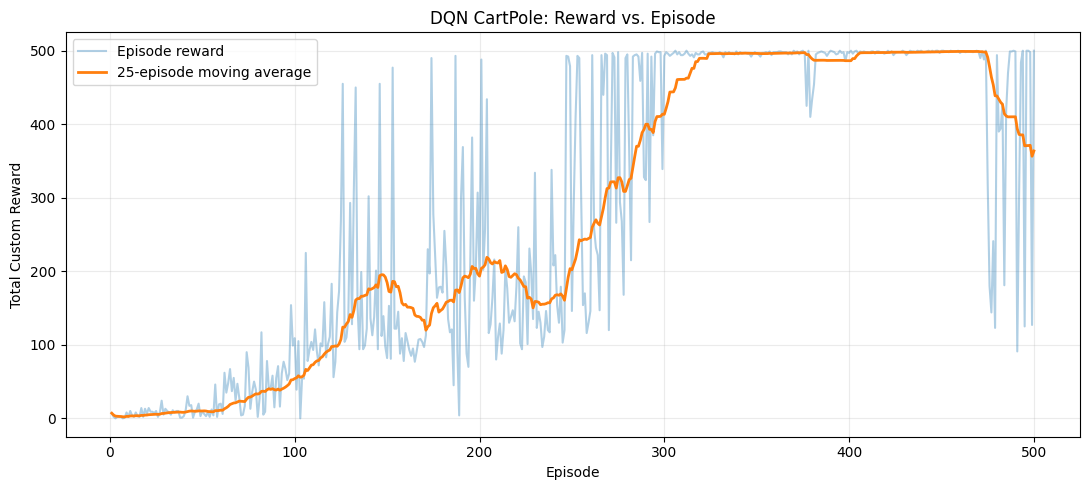

In [11]:
def add_moving_average(df, column, window=25):
    return df[column].rolling(window=window, min_periods=1).mean()


window = 25

plt.figure(figsize=(11, 5))
plt.plot(history_df["episode"], history_df["total_reward"], alpha=0.35, label="Episode reward")
plt.plot(
    history_df["episode"],
    add_moving_average(history_df, "total_reward", window),
    linewidth=2,
    label=f"{window}-episode moving average",
)
plt.xlabel("Episode")
plt.ylabel("Total Custom Reward")
plt.title("DQN CartPole: Reward vs. Episode")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

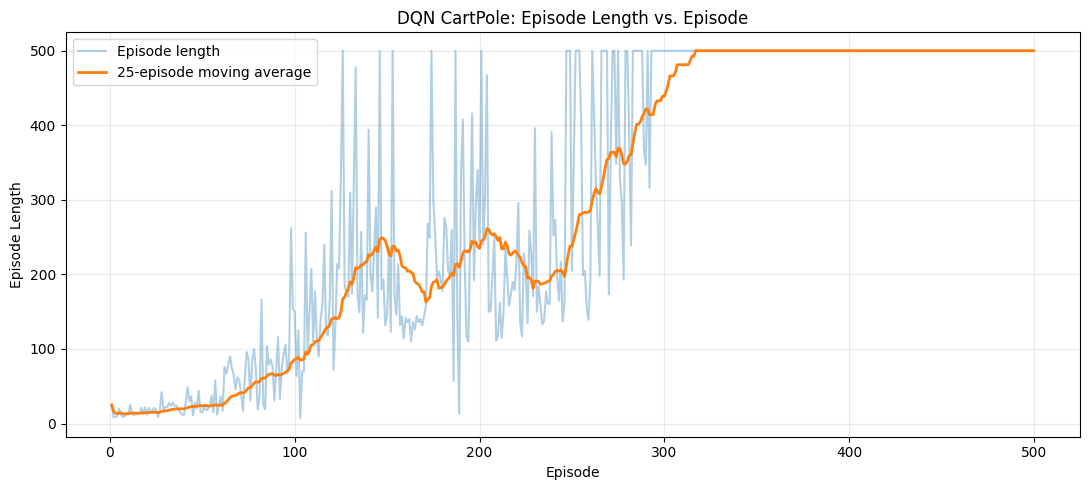

In [12]:
plt.figure(figsize=(11, 5))
plt.plot(history_df["episode"], history_df["episode_length"], alpha=0.35, label="Episode length")
plt.plot(
    history_df["episode"],
    add_moving_average(history_df, "episode_length", window),
    linewidth=2,
    label=f"{window}-episode moving average",
)
plt.xlabel("Episode")
plt.ylabel("Episode Length")
plt.title("DQN CartPole: Episode Length vs. Episode")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

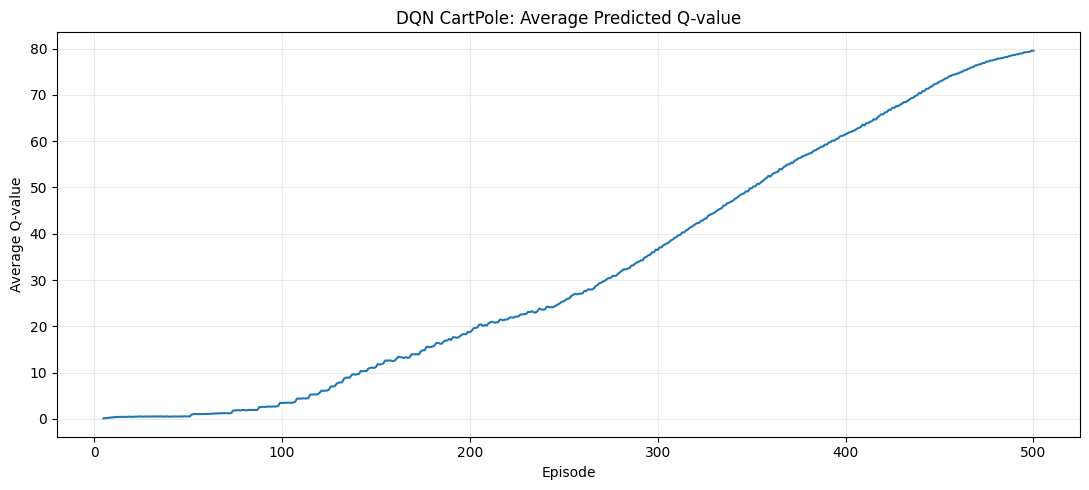

In [13]:
plt.figure(figsize=(11, 5))
plt.plot(history_df["episode"], history_df["average_q"])
plt.xlabel("Episode")
plt.ylabel("Average Q-value")
plt.title("DQN CartPole: Average Predicted Q-value")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

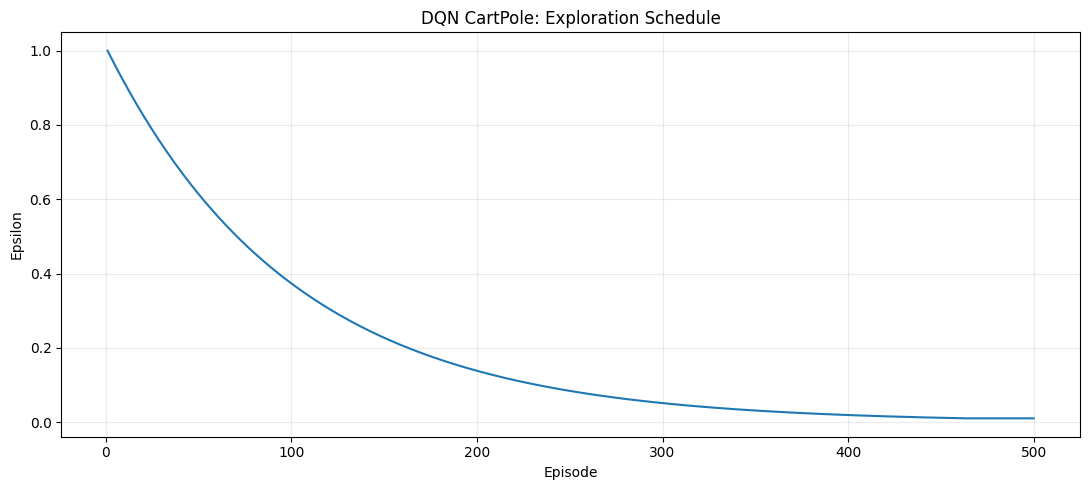

In [14]:
plt.figure(figsize=(11, 5))
plt.plot(history_df["episode"], history_df["epsilon"])
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("DQN CartPole: Exploration Schedule")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

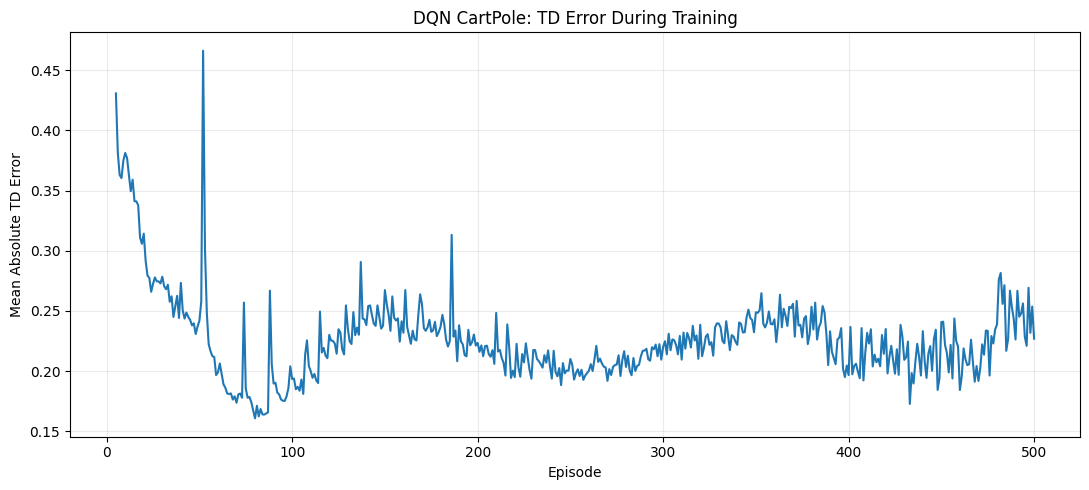

In [15]:
plt.figure(figsize=(11, 5))
plt.plot(history_df["episode"], history_df["td_error"])
plt.xlabel("Episode")
plt.ylabel("Mean Absolute TD Error")
plt.title("DQN CartPole: TD Error During Training")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

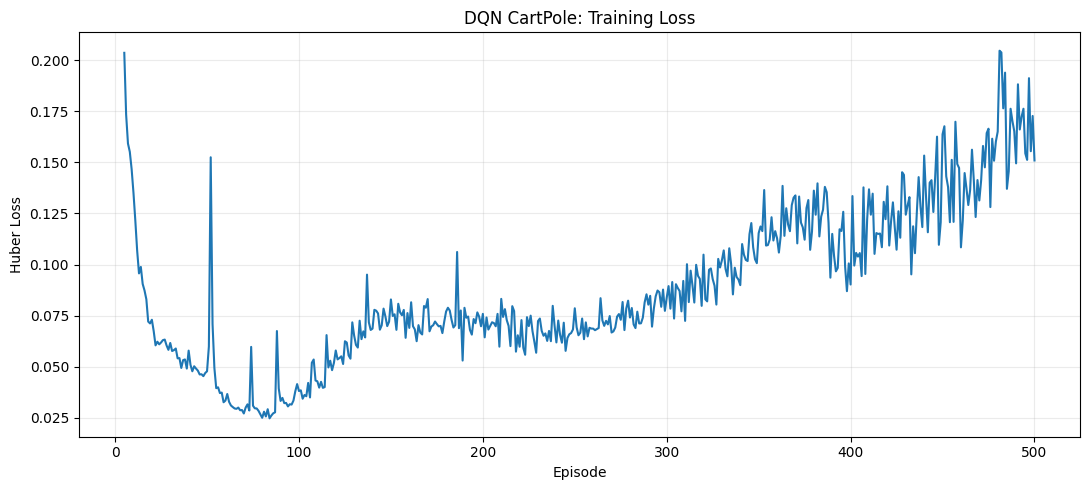

In [16]:
plt.figure(figsize=(11, 5))
plt.plot(history_df["episode"], history_df["loss"])
plt.xlabel("Episode")
plt.ylabel("Huber Loss")
plt.title("DQN CartPole: Training Loss")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 14. Evaluate the trained policy

Training uses exploration. Evaluation should test the learned policy itself, so we set

$$
\boxed{\epsilon=0}
$$

conceptually and always choose

$$
\boxed{
A_t=\arg\max_a Q(S_t,a;\theta)
}
$$

The evaluation below reports both:

- total custom reward,
- episode length.

In [17]:
def evaluate_agent(agent, episodes=10, seed=10_000):
    env = CartpoleEnvironment(gym.make("CartPole-v1"))

    records = []

    for episode in range(episodes):
        state, info = env.reset(seed=seed + episode)

        done = False
        total_reward = 0.0
        episode_length = 0

        while not done:
            action = agent.select_action(state, training=False)

            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            total_reward += reward
            episode_length += 1

        records.append(
            {
                "episode": episode + 1,
                "total_reward": total_reward,
                "episode_length": episode_length,
            }
        )

    env.close()
    return pd.DataFrame(records)


evaluation_df = evaluate_agent(agent, episodes=10)
display(evaluation_df)

print("Mean total reward :", evaluation_df["total_reward"].mean())
print("Mean episode length:", evaluation_df["episode_length"].mean())

,episode,total_reward,episode_length
0,1,500.0,500
1,2,500.0,500
2,3,442.0,500
3,4,282.0,500
4,5,500.0,500
5,6,333.0,500
6,7,500.0,500
7,8,370.0,500
8,9,500.0,500
9,10,500.0,500


Mean total reward : 442.7
Mean episode length: 500.0


## 15. Inspect the learned action values

For any state, the DQN returns two Q-values:

$$
[Q(s,\text{Left}),Q(s,\text{Right})]
$$

The action with the larger value is the greedy action.

In [18]:
inspect_env = CartpoleEnvironment(gym.make("CartPole-v1"))
state, info = inspect_env.reset(seed=123)

q_values = agent.q_network(
    tf.convert_to_tensor(state[None, :], dtype=tf.float32),
    training=False,
).numpy()[0]

chosen_action = int(np.argmax(q_values))

print("Scaled state:", state)
print("Q(Left)     :", q_values[0])
print("Q(Right)    :", q_values[1])
print("Greedy action:", chosen_action, "->", "Left" if chosen_action == 0 else "Right")

inspect_env.close()

Scaled state: [ 0.0076 -0.0223 -0.1332 -0.009 ]
Q(Left)     : 80.59111
Q(Right)    : 80.503654
Greedy action: 0 -> Left


## 16. Save the trained agent

The supplied code saves an agent folder such as:

```python
AGENT_PATH = "cart_pole_agent2"
```

This self-contained version saves:

- online-network weights,
- target-network weights,
- epsilon,
- environment-step counter,
- gradient-step counter.

In [19]:
AGENT_PATH = "cart_pole_agent"

agent.save(AGENT_PATH)

print("Saved files:")
for filename in sorted(os.listdir(AGENT_PATH)):
    print(" -", filename)

Saved files:
 - agent_state.npz
 - q_network.weights.h5
 - target_network.weights.h5


## 17. Load the saved agent

A new DQN object can restore the saved neural-network weights and training counters.

In [20]:
loaded_agent = DQNAgent(
    learning_rate=1e-3,
    discount_factor=0.99,
    replay_size=100_000,
    exploration=1.0,
    min_exploration=0.01,
    exploration_decay=1.01,
    learn_after_steps=3,
    update_target_after_steps=1_000,
)

loaded_agent.load(AGENT_PATH)

print("Restored epsilon:", loaded_agent.epsilon)
print("Restored environment steps:", loaded_agent.total_environment_steps)
print("Restored gradient steps:", loaded_agent.total_gradient_steps)

Restored epsilon: 0.01
Restored environment steps: 156035
Restored gradient steps: 155972


## 18. Record a greedy evaluation episode

The following cell runs the trained agent with no exploration, captures rendered frames, saves an MP4 file, and displays it directly in Colab.

In [21]:
def record_episode(agent, filename="cartpole_dqn.mp4", seed=20_000, fps=30):
    env = CartpoleEnvironment(
        gym.make("CartPole-v1", render_mode="rgb_array")
    )

    state, info = env.reset(seed=seed)
    frames = [env.render()]

    done = False
    total_reward = 0.0
    episode_length = 0

    while not done:
        action = agent.select_action(state, training=False)

        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        frame = env.render()
        frames.append(frame)

        total_reward += reward
        episode_length += 1

    env.close()

    imageio.mimsave(filename, frames, fps=fps)

    print("Saved:", filename)
    print("Total custom reward:", total_reward)
    print("Episode length:", episode_length)

    return filename


video_file = record_episode(agent)
display(Video(video_file, embed=True))

Saved: cartpole_dqn.mp4
Total custom reward: 175.0
Episode length: 500


## 19. Library classes:

 library classes:

| Original component | This notebook |
|---|---|
| `CartpoleEnvironment(GymEnvironment)` | `CartpoleEnvironment(gym.Wrapper)` |
| `DeepQLearning` | `DQNAgent` |
| `Agent.train(...)` | explicit training loop |
| replay memory inside algorithm | `ReplayBuffer` |
| Q network | `build_q_network()` |
| target network | `agent.target_network` |
| exploration tracker | `history["epsilon"]` |
| average Q metric | `history["average_q"]` |
| value error metric | `history["td_error"]` |
| total reward metric | `history["total_reward"]` |
| episode length metric | `history["episode_length"]` |
| `SaveAgent` / `agent.save()` | `DQNAgent.save()` |
| `agent.load()` | `DQNAgent.load()` |
| live/video viewer | `record_episode()` |



## 20. DQN algorithm

```text
Input:
    CartPole environment
    online Q-network Q(s,a;theta)
    target Q-network Q(s,a;theta-)
    replay buffer D
    discount factor gamma
    exploration epsilon

Initialize:
    online-network weights theta randomly
    target weights theta- = theta
    empty replay buffer D

For each episode:

    Reset environment and observe S

    Repeat until terminal:

        1. Choose action using epsilon-greedy

           With probability epsilon:
               choose random action A

           Otherwise:
               A = argmax_a Q(S,a;theta)

        2. Execute A

           Observe reward R
           Observe next state S'
           Observe terminal flag D_done

        3. Store transition

           (S, A, R, S', D_done)

           in replay memory

        4. Sample a random mini-batch

        5. Compute DQN target

           Y = R + gamma(1-D_done)
                     max_a' Q(S',a';theta-)

        6. Compute current prediction

           Q_pred = Q(S,A;theta)

        7. Minimize prediction error

           Loss(Y, Q_pred)

           Update theta using gradient descent

        8. Periodically copy

           theta- <- theta

        9. Set

           S <- S'

    Decay epsilon

Output:
    trained Q-network
```

## 21. Key interpretation

The complete learning path is

$$
\boxed{
S_t
\rightarrow
Q(S_t,\cdot;\theta)
\rightarrow
A_t
\rightarrow
R_{t+1},S_{t+1}
\rightarrow
Y_t
\rightarrow
\text{TD error}
\rightarrow
\text{network update}
}
$$

The neural network does **not** directly predict the action. It predicts a Q-value for each possible action.

For CartPole:

$$
Q(S_t,\cdot;\theta)
=
[
Q(S_t,\text{Left};\theta),
Q(S_t,\text{Right};\theta)
]
$$

The policy then chooses the action from those values.

This is the main connection between ordinary Q-learning and DQN:

$$
\boxed{
\text{Q-table}
\quad\longrightarrow\quad
\text{neural-network Q-function}
}
$$

## 22. Portfolio notes

This experiment demonstrates:

- custom environment and reward design,
- continuous-state preprocessing,
- neural-network value-function approximation,
- off-policy temporal-difference learning,
- experience replay,
- target-network stabilization,
- epsilon-greedy exploration,
- model persistence,
- training diagnostics,
- and policy evaluation through simulation.

A useful portfolio discussion point is that **reward and episode length are not identical in this experiment**. The custom reward gives `+1` only in the desired stable region, `0` in intermediate states, and `-1` at the defined control limits. Therefore, episode length should be evaluated alongside total reward.

## References

1. Mnih, V., Kavukcuoglu, K., Silver, D., et al. (2015). **Human-level control through deep reinforcement learning.** *Nature*, 518, 529–533. https://doi.org/10.1038/nature14236

2. Gymnasium documentation: **Cart Pole**. https://gymnasium.farama.org/environments/classic_control/cart_pole/

3. Gymnasium documentation: **Basic Usage**. https://gymnasium.farama.org/introduction/basic_usage/